# 📊 TUGAS 2C — Bag of Words (BoW) Review Aplikasi Honest

---

**Dataset:** `cleandata.csv` — Review aplikasi Honest (Kartu Kredit Digital)  
**Fokus:** Implementasi Bag of Words pada 50 review (25 positif + 25 negatif)

## 📚 Tujuan Pembelajaran

1. Memahami konsep Bag of Words (BoW) dalam pemrosesan teks
2. Melakukan implementasi BoW secara manual (tokenisasi, frekuensi kata, vektor)
3. Menggunakan `CountVectorizer` dari scikit-learn untuk BoW otomatis
4. Mengaplikasikan BoW pada 50 review Honest (25 positif + 25 negatif)
5. Menganalisis perbandingan kata dominan antara review positif dan negatif

## 1) 📖 Konsep Bag of Words (BoW)

**Bag of Words** adalah teknik representasi teks dalam bentuk vektor berdasarkan frekuensi kemunculan kata. Setiap dokumen direpresentasikan sebagai "kantong kata" tanpa memperhatikan urutan atau struktur gramatikal.

### Langkah-langkah BoW:
1. **Tokenisasi** — Memecah teks menjadi kata-kata individual
2. **Bangun Vocabulary** — Kumpulkan semua kata unik dari seluruh dokumen
3. **Vektorisasi** — Hitung frekuensi setiap kata di setiap dokumen

### Kelebihan & Kekurangan:

| Aspek | Keterangan |
|-------|-----------|
| ✅ Kelebihan | Sederhana, mudah diimplementasikan, efektif untuk klasifikasi teks dasar |
| ✅ Kelebihan | Tidak memerlukan model bahasa yang kompleks |
| ❌ Kekurangan | Mengabaikan urutan kata (kehilangan konteks) |
| ❌ Kekurangan | Menghasilkan matriks sparse berukuran besar |
| ❌ Kekurangan | Tidak menangkap makna semantik kata |

## 2) 📦 Install & Import Library

In [27]:
%pip install nltk scikit-learn matplotlib Sastrawi -q

Note: you may need to restart the kernel to use updated packages.


In [28]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import warnings
warnings.filterwarnings('ignore')

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

print("✅ Semua library berhasil diimport!")

✅ Semua library berhasil diimport!


## 3) 🔧 Demo BoW Manual (Bahasa Inggris)

Untuk memahami konsep BoW, kita mulai dengan contoh sederhana menggunakan teks bahasa Inggris.

In [29]:
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Contoh teks
text = "The quick brown fox jumps over the lazy dog. The dog barked at the fox."
print(f"📌 Teks asli:\n{text}")

# Step 1: Tokenisasi
tokens = word_tokenize(text.lower())
print(f"\n📌 Step 1 — Tokenisasi ({len(tokens)} token):")
print(tokens)

# Step 2: Lemmatisasi
lemmatizer = WordNetLemmatizer()
lemmatized = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha()]
print(f"\n📌 Step 2 — Lemmatisasi ({len(lemmatized)} kata):")
print(lemmatized)

# Step 3: Vocabulary (kata unik)
vocab = sorted(set(lemmatized))
print(f"\n📌 Step 3 — Vocabulary ({len(vocab)} kata unik):")
print(vocab)

📌 Teks asli:
The quick brown fox jumps over the lazy dog. The dog barked at the fox.

📌 Step 1 — Tokenisasi (17 token):
['the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.', 'the', 'dog', 'barked', 'at', 'the', 'fox', '.']

📌 Step 2 — Lemmatisasi (15 kata):
['the', 'quick', 'brown', 'fox', 'jump', 'over', 'the', 'lazy', 'dog', 'the', 'dog', 'barked', 'at', 'the', 'fox']

📌 Step 3 — Vocabulary (10 kata unik):
['at', 'barked', 'brown', 'dog', 'fox', 'jump', 'lazy', 'over', 'quick', 'the']


In [30]:
# Step 4: Frekuensi kata
freq = Counter(lemmatized)
print("📌 Step 4 — Frekuensi Kata:")
for word, count in freq.most_common():
    bar = '█' * count
    print(f"  {word:12s}: {bar} ({count})")

📌 Step 4 — Frekuensi Kata:
  the         : ████ (4)
  fox         : ██ (2)
  dog         : ██ (2)
  quick       : █ (1)
  brown       : █ (1)
  jump        : █ (1)
  over        : █ (1)
  lazy        : █ (1)
  barked      : █ (1)
  at          : █ (1)


In [31]:
# Step 5: Word-to-Index mapping & Vektor BoW
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
print("📌 Step 5 — Word-to-Index Mapping:")
print(word_to_idx)

# Buat vektor BoW
bow_vector = [0] * len(vocab)
for word in lemmatized:
    bow_vector[word_to_idx[word]] += 1

print(f"\n📌 Vektor BoW (panjang = {len(bow_vector)}):")
for word, idx in word_to_idx.items():
    print(f"  {word:12s} (idx {idx:2d}): {bow_vector[idx]}")

📌 Step 5 — Word-to-Index Mapping:
{'at': 0, 'barked': 1, 'brown': 2, 'dog': 3, 'fox': 4, 'jump': 5, 'lazy': 6, 'over': 7, 'quick': 8, 'the': 9}

📌 Vektor BoW (panjang = 10):
  at           (idx  0): 1
  barked       (idx  1): 1
  brown        (idx  2): 1
  dog          (idx  3): 2
  fox          (idx  4): 2
  jump         (idx  5): 1
  lazy         (idx  6): 1
  over         (idx  7): 1
  quick        (idx  8): 1
  the          (idx  9): 4


## 4) 🤖 BoW Otomatis dengan CountVectorizer

Menggunakan `CountVectorizer` dari scikit-learn untuk membuat representasi BoW secara otomatis. Ini jauh lebih efisien dibanding implementasi manual, terutama untuk dataset besar.

In [32]:
# 3 dokumen contoh
documents = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "cats and dogs are friends"
]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(documents)

print("📌 Vocabulary:")
print(vectorizer.get_feature_names_out())
print(f"\n📌 BoW Matrix (shape: {bow_matrix.shape}):")
df_bow = pd.DataFrame(bow_matrix.toarray(),
                       columns=vectorizer.get_feature_names_out(),
                       index=[f'Doc {i+1}' for i in range(len(documents))])
print(df_bow)

print("\n📌 Penjelasan:")
print("  - Setiap baris = 1 dokumen")
print("  - Setiap kolom = 1 kata dari vocabulary")
print("  - Nilai = frekuensi kemunculan kata di dokumen tersebut")

📌 Vocabulary:
['and' 'are' 'cat' 'cats' 'dog' 'dogs' 'friends' 'log' 'mat' 'on' 'sat'
 'the']

📌 BoW Matrix (shape: (3, 12)):
       and  are  cat  cats  dog  dogs  friends  log  mat  on  sat  the
Doc 1    0    0    1     0    0     0        0    0    1   1    1    2
Doc 2    0    0    0     0    1     0        0    1    0   1    1    2
Doc 3    1    1    0     1    0     1        1    0    0   0    0    0

📌 Penjelasan:
  - Setiap baris = 1 dokumen
  - Setiap kolom = 1 kata dari vocabulary
  - Nilai = frekuensi kemunculan kata di dokumen tersebut


## 5) 📂 Load Dataset Review Honest

Memuat `cleandata.csv` dan menyiapkan data untuk analisis BoW.

In [33]:
df = pd.read_csv('cleandata.csv')
print(f"Dataset berhasil dimuat!")
print(f"Jumlah baris : {df.shape[0]:,}")
print(f"Jumlah kolom : {df.shape[1]}")
print("\n📌 Distribusi Score:")
print(df['score'].value_counts().sort_index())
df.head()

Dataset berhasil dimuat!
Jumlah baris : 39,164
Jumlah kolom : 4

📌 Distribusi Score:
score
1     2961
2      464
3      561
4      715
5    34463
Name: count, dtype: int64


,score,content,text_final,reviewCreatedVersion
0,5,ini adalah pertama kali saya menggunakan kartu...,kali kartu kredit cocok anak muda update alam ...,3.831.0
1,5,"pengajuan berhasil, pelayanan utk CS atas nama...",hasil layan cs nama sangat sopan jelas sangat ...,3.833.1
2,5,Pengajuan cepat dan aman..,cepat aman,3.833.1
3,5,cs Ridwan terbaik,cs baik,3.833.1
4,5,penjelasan yang baik oleh mba rima,jelas baik,3.833.1


## 6) 🎯 Sampling 50 Review (25 Positif + 25 Negatif)

Mengambil sample **50 review** untuk analisis BoW:
- **25 review positif** (score 4-5) — dari total 35,178 review positif
- **25 review negatif** (score 1-2) — dari total 3,425 review negatif

> 📌 Sampling menggunakan `random_state=42` agar hasil reproducible.

In [34]:
pos_df = df[df['score'] >= 4].sample(25, random_state=42)
neg_df = df[df['score'] <= 2].sample(25, random_state=42)

df_sample = pd.concat([pos_df, neg_df]).reset_index(drop=True)
df_sample['label'] = ['positif'] * 25 + ['negatif'] * 25

print(f"📌 Total sample: {len(df_sample)}")
print(f"📌 Positif (score 4-5): {len(pos_df)}")
print(f"📌 Negatif (score 1-2): {len(neg_df)}")
print(f"\n📌 Distribusi Score pada Sample:")
print(df_sample['score'].value_counts().sort_index())
print(f"\n📌 Contoh Review Sample:")
df_sample[['score', 'label', 'text_final']].head(6)

📌 Total sample: 50
📌 Positif (score 4-5): 25
📌 Negatif (score 1-2): 25

📌 Distribusi Score pada Sample:
score
1    22
2     3
4     1
5    24
Name: count, dtype: int64

📌 Contoh Review Sample:


,score,label,text_final
0,5,positif,ubah mode cicil
1,5,positif,mudah
2,5,positif,mudah sekali menit langsung acc
3,5,positif,terima kasih orgnya ramah jelas nerangin terim...
4,5,positif,mudahh sekali
5,4,positif,mudah cepat


## 7) 🔧 Preprocessing Teks (Stopword Removal)

Kolom `text_final` sudah melalui stemming. Kita tambahkan stopword removal untuk BoW yang lebih clean.

In [35]:
factory = StopWordRemoverFactory()
stopwords_id = set(factory.get_stop_words())

def clean_for_bow(text):
    words = str(text).split()
    filtered = [w for w in words if w not in stopwords_id and len(w) > 2]
    return ' '.join(filtered)

df_sample['bow_text'] = df_sample['text_final'].apply(clean_for_bow)

print("📌 Contoh preprocessing BoW:")
for i in range(3):
    print(f"\n  Original  : {df_sample['text_final'].iloc[i][:100]}...")
    print(f"  BoW Ready : {df_sample['bow_text'].iloc[i][:100]}...")

📌 Contoh preprocessing BoW:

  Original  : ubah mode cicil...
  BoW Ready : ubah mode cicil...

  Original  : mudah...
  BoW Ready : mudah...

  Original  : mudah sekali menit langsung acc...
  BoW Ready : mudah sekali menit langsung acc...


## 7b) ✂️ Tokenisasi Berbasis Regex

Membandingkan 3 metode tokenisasi menggunakan modul `re`:
1. **Whitespace split** — `re.split(r'\s+')`
2. **Word-only** — `re.findall(r'\b[a-zA-Z]+\b')` (hanya huruf)
3. **Alphanumeric** — `re.findall(r'\b\w+\b')` (huruf + angka)

Mendemonstrasikan bagaimana pemilihan regex pattern mempengaruhi hasil tokenisasi untuk pipeline BoW.

📊 Perbandingan 3 Metode Tokenisasi Regex:

  Whitespace Split:
    Avg tokens/review : 8.5
    Total tokens      : 426
    Unique tokens     : 214

  Word-Only (huruf):
    Avg tokens/review : 8.5
    Total tokens      : 426
    Unique tokens     : 214

  Alphanumeric:
    Avg tokens/review : 8.5
    Total tokens      : 426
    Unique tokens     : 214


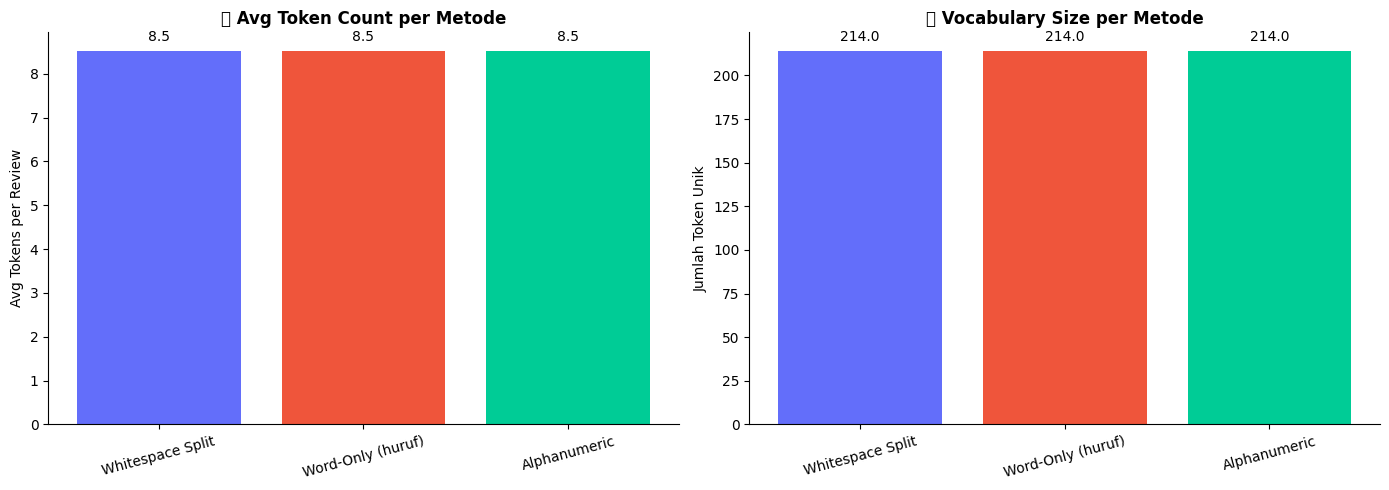


📌 Top 20 Token (Word-Only setelah regex clean):
   tidak                ██████████████████████████████ 25
   kasih                ██████████████████ 15
   terima               ████████████████ 14
   data                 ██████████████ 12
   kartu                ██████████ 9
   mudah                ████████ 7
   kredit               ████████ 7
   jelas                ███████ 6
   lama                 ███████ 6
   tolak                ███████ 6
   belum                ███████ 6
   sekali               ██████ 5
   acc                  ██████ 5
   proses               ██████ 5
   bener                ██████ 5
   bunga                ██████ 5
   bayar                ██████ 5
   ramah                ████ 4
   bantu                ████ 4
   limit                ████ 4


In [37]:
# ── Regex cleaning function (needed for regex-based tokenisasi) ──
def regex_clean(text):
    if pd.isna(text):
        return ''
    text = str(text).lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_sample['content_regex_clean'] = df_sample['text_final'].apply(regex_clean)

# ── 3 metode tokenisasi ──
def tok_whitespace(text):
    return re.split(r'\s+', str(text).strip())

def tok_word_only(text):
    return re.findall(r'\b[a-zA-Z]+\b', str(text))

def tok_alphanum(text):
    return re.findall(r'\b\w+\b', str(text))

# ── Terapkan 3 metode pada sample ──
methods = {
    'Whitespace Split': tok_whitespace,
    'Word-Only (huruf)': tok_word_only,
    'Alphanumeric': tok_alphanum,
}

print("📊 Perbandingan 3 Metode Tokenisasi Regex:")
print("=" * 60)

stats = {}
for name, func in methods.items():
    tokens_list = df_sample['content_regex_clean'].apply(func)
    avg_tokens = tokens_list.apply(len).mean()
    all_tokens = [t for tokens in tokens_list for t in tokens if t]
    unique_tokens = len(set(all_tokens))
    stats[name] = {'avg_tokens': avg_tokens, 'unique': unique_tokens, 'total': len(all_tokens)}
    print(f"\n  {name}:")
    print(f"    Avg tokens/review : {avg_tokens:.1f}")
    print(f"    Total tokens      : {len(all_tokens):,}")
    print(f"    Unique tokens     : {unique_tokens:,}")

# ── Visualisasi perbandingan ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg tokens per method
method_names = list(stats.keys())
avg_vals = [stats[m]['avg_tokens'] for m in method_names]
colors_tok = ['#636EFA', '#EF553B', '#00CC96']
bars = axes[0].bar(method_names, avg_vals, color=colors_tok)
axes[0].bar_label(bars, fmt='{:.1f}', padding=5)
axes[0].set_ylabel('Avg Tokens per Review')
axes[0].set_title('📊 Avg Token Count per Metode', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(axis='x', rotation=15)

# Unique token count
unique_vals = [stats[m]['unique'] for m in method_names]
bars2 = axes[1].bar(method_names, unique_vals, color=colors_tok)
axes[1].bar_label(bars2, fmt='{:,}', padding=5)
axes[1].set_ylabel('Jumlah Token Unik')
axes[1].set_title('🔤 Vocabulary Size per Metode', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ── Top 20 tokens (metode word-only) ──
all_word_tokens = [t for tokens in df_sample['content_regex_clean'].apply(tok_word_only) for t in tokens if len(t) > 2]
from collections import Counter
top20 = Counter(all_word_tokens).most_common(20)
print(f"\n📌 Top 20 Token (Word-Only setelah regex clean):")
for word, count in top20:
    bar = '█' * int(count / top20[0][1] * 30)
    print(f"   {word:20s} {bar} {count}")

## 8) 📊 Bag of Words pada 50 Review Sample

Mengaplikasikan `CountVectorizer` pada 50 review yang sudah dipreprocessing. Hasilnya berupa sparse matrix berukuran **(50 × 204)** — artinya dari 50 review terbentuk **204 kata unik** sebagai vocabulary.

In [38]:
vectorizer_50 = CountVectorizer()
bow_50 = vectorizer_50.fit_transform(df_sample['bow_text'])

print(f"📌 BoW Matrix Shape: {bow_50.shape}")
print(f"📌 Jumlah Dokumen: {bow_50.shape[0]}")
print(f"📌 Jumlah Vocabulary: {bow_50.shape[1]}")
print(f"📌 Sparsity: {(1 - bow_50.nnz / (bow_50.shape[0] * bow_50.shape[1])) * 100:.2f}%")
print(f"📌 Non-zero entries: {bow_50.nnz:,}")

print("\n📌 Insight:")
print(f"  → Dari 50 review terbentuk {bow_50.shape[1]} kata unik (vocabulary)")
print(f"  → Sparsity sangat tinggi (~96%) — sebagian besar sel bernilai 0")
print(f"  → Rata-rata setiap review hanya menggunakan {bow_50.nnz / bow_50.shape[0]:.1f} kata unik")

print("\n📌 Sample BoW Matrix (5 dokumen pertama, 10 kata pertama):")
feature_names = vectorizer_50.get_feature_names_out()
df_bow_sample = pd.DataFrame(bow_50[:5, :10].toarray(),
                              columns=feature_names[:10],
                              index=[f'Review {i+1}' for i in range(5)])
print(df_bow_sample)

📌 BoW Matrix Shape: (50, 204)
📌 Jumlah Dokumen: 50
📌 Jumlah Vocabulary: 204
📌 Sparsity: 96.63%
📌 Non-zero entries: 344

📌 Insight:
  → Dari 50 review terbentuk 204 kata unik (vocabulary)
  → Sparsity sangat tinggi (~96%) — sebagian besar sel bernilai 0
  → Rata-rata setiap review hanya menggunakan 6.9 kata unik

📌 Sample BoW Matrix (5 dokumen pertama, 10 kata pertama):
          acc  admin  adminnya  aja  akun  ambil  andriansyah  aneh  antusias  \
Review 1    0      0         0    0     0      0            0     0         0   
Review 2    0      0         0    0     0      0            0     0         0   
Review 3    1      0         0    0     0      0            0     0         0   
Review 4    0      0         0    0     0      0            0     0         0   
Review 5    0      0         0    0     0      0            0     0         0   

          apa  
Review 1    0  
Review 2    0  
Review 3    0  
Review 4    0  
Review 5    0  


## 9) 📊 Top 15 Kata: Positif vs Negatif

Membandingkan kata-kata yang paling sering muncul antara review positif dan negatif. Visualisasi ini menunjukkan perbedaan topik yang dibicarakan oleh pengguna puas vs tidak puas.

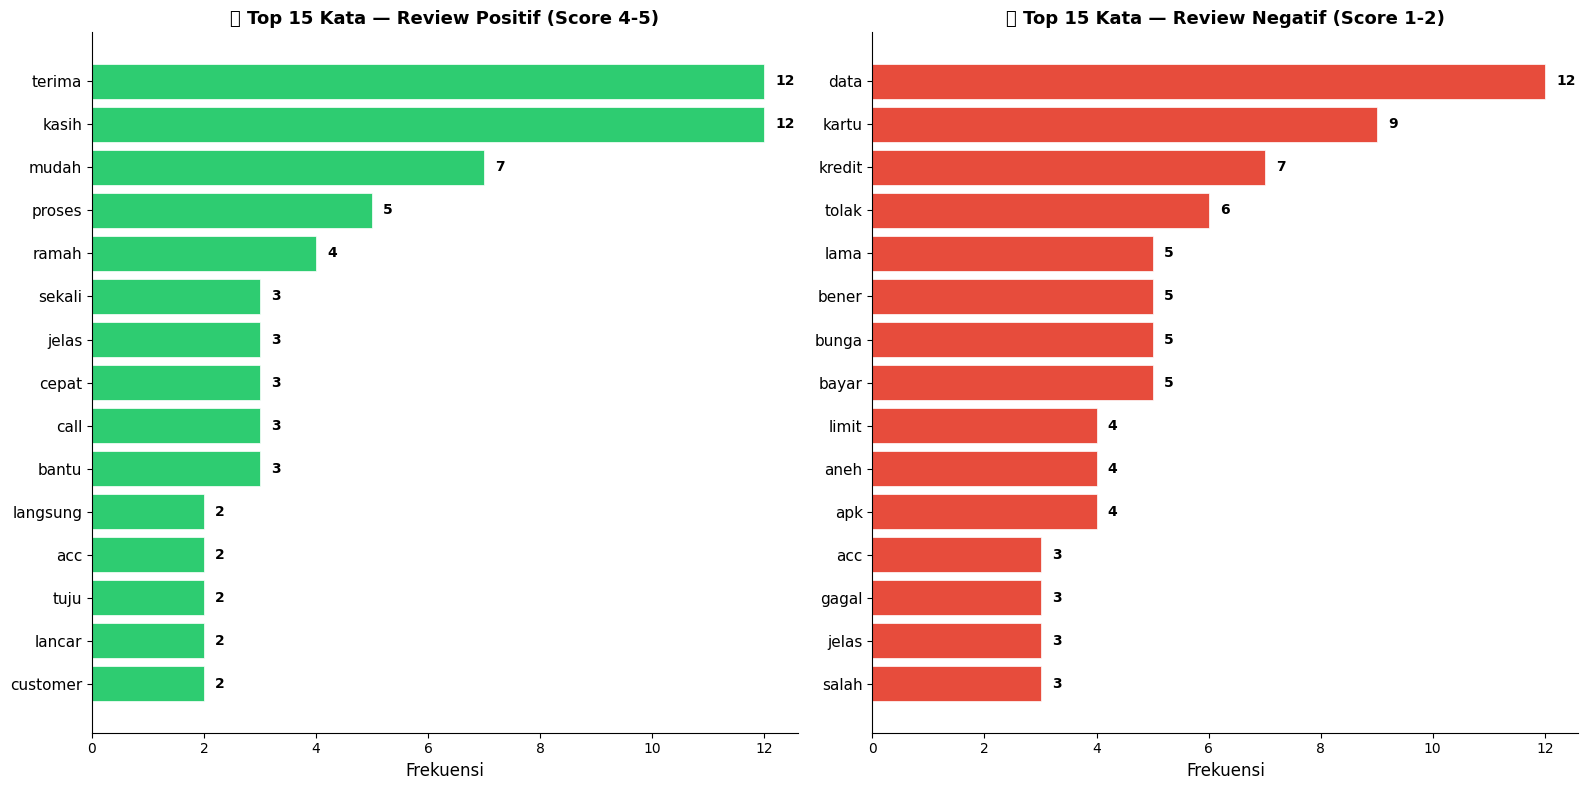


📌 Review Positif didominasi: 'terima' (12×), 'kasih' (12×), 'mudah' (7×)
   → Tema: apresiasi (terima kasih), kemudahan penggunaan, proses cepat
📌 Review Negatif didominasi: 'data' (12×), 'kartu' (9×), 'kredit' (7×)
   → Tema: masalah data, kartu kredit, penolakan, bunga
📌 Kata 'acc' muncul di kedua sisi — konteks berbeda (approval vs rejection)


In [39]:
pos_texts = df_sample[df_sample['label'] == 'positif']['bow_text']
neg_texts = df_sample[df_sample['label'] == 'negatif']['bow_text']

def get_top_words(texts, n=15):
    all_words = ' '.join(texts).split()
    return Counter(all_words).most_common(n)

top_pos = get_top_words(pos_texts)
top_neg = get_top_words(neg_texts)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Positif ──
words_p, counts_p = zip(*top_pos)
axes[0].barh(range(len(words_p)), counts_p, color='#2ecc71', edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(words_p)))
axes[0].set_yticklabels(words_p, fontsize=11)
axes[0].set_xlabel('Frekuensi', fontsize=12)
axes[0].set_title('📊 Top 15 Kata — Review Positif (Score 4-5)', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate(counts_p):
    axes[0].text(v + 0.2, i, f'{v}', va='center', fontsize=10, fontweight='bold')

# ── Negatif ──
words_n, counts_n = zip(*top_neg)
axes[1].barh(range(len(words_n)), counts_n, color='#e74c3c', edgecolor='white', linewidth=0.5)
axes[1].set_yticks(range(len(words_n)))
axes[1].set_yticklabels(words_n, fontsize=11)
axes[1].set_xlabel('Frekuensi', fontsize=12)
axes[1].set_title('📊 Top 15 Kata — Review Negatif (Score 1-2)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate(counts_n):
    axes[1].text(v + 0.2, i, f'{v}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Insight ──
print(f"\n📌 Review Positif didominasi: '{words_p[0]}' ({counts_p[0]}×), '{words_p[1]}' ({counts_p[1]}×), '{words_p[2]}' ({counts_p[2]}×)")
print(f"   → Tema: apresiasi (terima kasih), kemudahan penggunaan, proses cepat")
print(f"📌 Review Negatif didominasi: '{words_n[0]}' ({counts_n[0]}×), '{words_n[1]}' ({counts_n[1]}×), '{words_n[2]}' ({counts_n[2]}×)")
print(f"   → Tema: masalah data, kartu kredit, penolakan, bunga")
print(f"📌 Kata 'acc' muncul di kedua sisi — konteks berbeda (approval vs rejection)")

## 10) 📊 BoW pada Full Dataset (39,164 Review)

Mengaplikasikan BoW pada **seluruh dataset** dengan parameter `min_df=5` (kata harus muncul minimal di 5 dokumen) dan `max_features=5000` untuk membatasi vocabulary.

> 📌 Hasilnya: sparse matrix dengan sparsity ~99.7% — tipikal untuk representasi BoW pada teks pendek.

📌 Full Dataset BoW:
  Shape          : (39164, 2579)
  Vocabulary size: 2,579
  Sparsity       : 99.73%
  Non-zero entries: 276,980


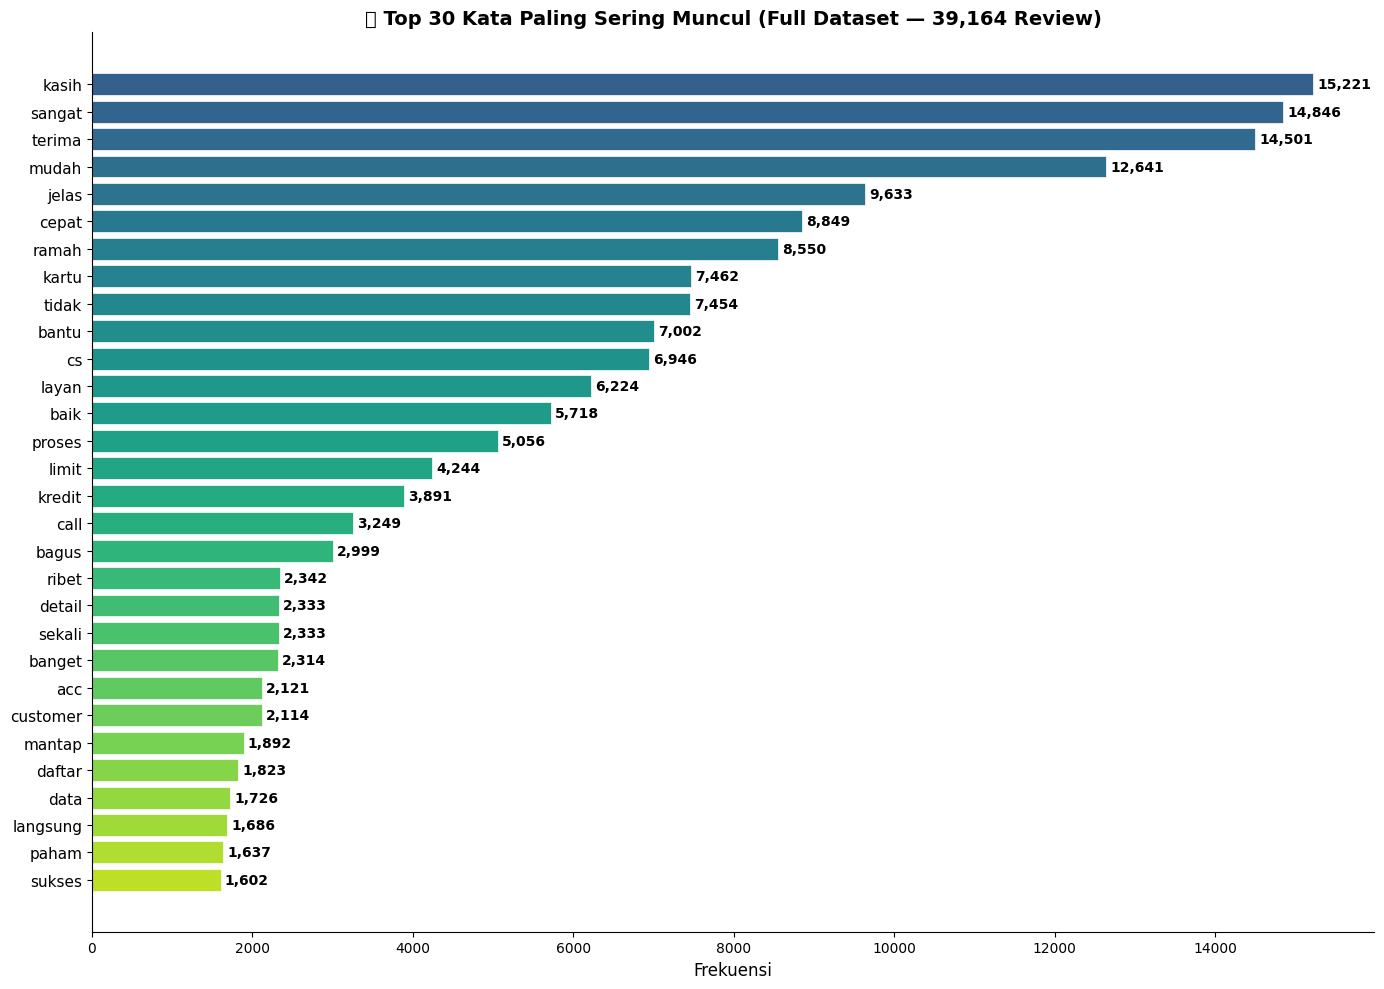


📌 Kata paling dominan: 'kasih' (15,221×) — bagian dari frasa 'terima kasih'
📌 Top 3: 'kasih' (15,221), 'sangat' (14,846), 'terima' (14,501)
📌 Kata negatif seperti 'ribet' (rank 19) dan 'limit' (rank 15) juga masuk Top 30
📌 Dominasi kata positif menunjukkan mayoritas review bernada puas (score 5 = 88% dataset)


In [40]:
vectorizer_full = CountVectorizer(min_df=5, max_features=5000)
bow_full = vectorizer_full.fit_transform(df['text_final'].astype(str))

print(f"📌 Full Dataset BoW:")
print(f"  Shape          : {bow_full.shape}")
print(f"  Vocabulary size: {len(vectorizer_full.get_feature_names_out()):,}")
print(f"  Sparsity       : {(1 - bow_full.nnz / (bow_full.shape[0] * bow_full.shape[1])) * 100:.2f}%")
print(f"  Non-zero entries: {bow_full.nnz:,}")

# Top 30 kata di full dataset
word_freq = np.array(bow_full.sum(axis=0)).flatten()
top_idx = word_freq.argsort()[-30:][::-1]
top_words_full = [(vectorizer_full.get_feature_names_out()[i], word_freq[i]) for i in top_idx]

words_f, counts_f = zip(*top_words_full)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(range(30), counts_f,
               color=plt.cm.viridis(np.linspace(0.3, 0.9, 30)),
               edgecolor='white', linewidth=0.5)
ax.set_yticks(range(30))
ax.set_yticklabels(words_f, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_title('📊 Top 30 Kata Paling Sering Muncul (Full Dataset — 39,164 Review)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i, v in enumerate(counts_f):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Insight ──
print(f"\n📌 Kata paling dominan: '{words_f[0]}' ({counts_f[0]:,}×) — bagian dari frasa 'terima kasih'")
print(f"📌 Top 3: '{words_f[0]}' ({counts_f[0]:,}), '{words_f[1]}' ({counts_f[1]:,}), '{words_f[2]}' ({counts_f[2]:,})")
print(f"📌 Kata negatif seperti 'ribet' (rank 19) dan 'limit' (rank 15) juga masuk Top 30")
print(f"📌 Dominasi kata positif menunjukkan mayoritas review bernada puas (score 5 = 88% dataset)")

## ✅ Kesimpulan

1. **Bag of Words (BoW)** mengubah teks menjadi representasi vektor berdasarkan frekuensi kata — proses: Tokenisasi → Vocabulary → Vektorisasi
2. **Demo manual** menunjukkan proses BoW step-by-step (tokenisasi, lemmatisasi, word-to-index, vektor frekuensi), dilanjutkan dengan `CountVectorizer` untuk otomisasi
3. **Sample 50 review** (25 positif + 25 negatif) menghasilkan matriks BoW **(50 × 204)** dengan sparsity ~96.6%:
   - Review **positif** didominasi: *terima* (12), *kasih* (12), *mudah* (7) — tema apresiasi & kemudahan
   - Review **negatif** didominasi: *data* (12), *kartu* (9), *kredit* (7) — tema masalah data & penolakan
4. **Full dataset** (39,164 review) menghasilkan vocabulary **2,579 kata** dengan sparsity 99.73%:
   - Top 3 kata: *kasih* (15,221), *sangat* (14,846), *terima* (14,501) — mencerminkan dominasi review positif (score 5 = 88%)
   - Kata negatif seperti *ribet* dan *limit* tetap masuk Top 30 meskipun review negatif hanya ~8.7% dari dataset
5. **Tokenisasi Regex** — Perbandingan 3 metode (`re.split`, `re.findall` word-only, `re.findall` alphanumeric) menunjukkan hasil identik (avg 8.5 token/review, 214 unique tokens) karena data sudah bersih pasca-stopword removal. Pada data mentah, perbedaan akan lebih signifikan karena regex word-only otomatis membuang angka dan tanda baca.
6. **Implikasi:** BoW efektif sebagai baseline untuk klasifikasi sentimen, namun keterbatasannya (mengabaikan urutan kata, sparse matrix besar) bisa diatasi dengan metode lanjutan seperti **TF-IDF** atau **Word Embedding**

---